In [26]:
import json

with open("data/downloads/infiniteBench/longbook_choice_eng.jsonl", encoding="utf-8") as f:
    data = [json.loads(line) for line in f]

In [2]:
import os
import streamlit as st

def get_diff_line(old_file, new_file):
    with open(old_file, 'r', encoding='utf-8') as f1, open(new_file, 'r', encoding='utf-8') as f2:
        old_lines = f1.readlines()
        new_lines = f2.readlines()

    max_len = max(len(old_lines), len(new_lines))

    for i in range(max_len):
        a = old_lines[i].rstrip("\n") if i < len(old_lines) else ""
        b = new_lines[i].rstrip("\n") if i < len(new_lines) else ""
        if a != b:
            return i + 1
    return None


def collect_diffs(old_root, new_root):
    diffs = []

    for dirpath, _, files in os.walk(old_root):
        rel = os.path.relpath(dirpath, old_root)
        new_dir = os.path.join(new_root, rel)

        for file in files:
            if not file.endswith(".txt"):
                continue

            old_file = os.path.join(dirpath, file)
            new_file = os.path.join(new_dir, file)

            if not os.path.exists(new_file):
                continue

            diff_line = get_diff_line(old_file, new_file)

            if diff_line is not None:
                diffs.append({
                    "name": f"{rel}/{file}",
                    "old": old_file,
                    "new": new_file,
                    "line": diff_line
                })

    return diffs


st.title("TXT Diff Viewer")

old_root = "Books_old"
new_root = "Books_new"

diffs = collect_diffs(old_root, new_root)

if "selected" not in st.session_state:
    st.session_state.selected = None

st.subheader("Pliki z różnicami")

for i, d in enumerate(diffs):
    if st.button(f"{d['name']} (linia {d['line']})", key=i):
        st.session_state.selected = d

st.divider()

if st.session_state.selected:
    d = st.session_state.selected

    col1, col2 = st.columns(2)

    with open(d["old"], "r", encoding="utf-8") as f:
        old_text = f.read()

    with open(d["new"], "r", encoding="utf-8") as f:
        new_text = f.read()

    with col1:
        st.subheader("Books_old")
        st.text_area("old", old_text, height=600)

    with col2:
        st.subheader("Books_new")
        st.text_area("new", new_text, height=600)

2026-05-17 23:56:31.790 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 23:56:31.842 
  command:

    streamlit run /home/mahuk/chunking-thesis/.venv/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-05-17 23:56:31.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 23:56:31.843 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 23:56:32.715 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 23:56:32.715 Session state does not function when running a script without `streamlit run`
2026-05-17 23:56:32.715 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 23:56:32.716 Thread 'MainThread': missin

In [1]:
import json
from pathlib import Path
from typing import List, Dict, Set, Tuple, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


class ChunkerAnalyzer:
    """Klasa do analizy chunkerów + RAG + retrieval"""

    ALLOWED_TAGS = {"h1", "h2", "h3", "h4", "h5", "h6", "p", "pre"}
    SPLITS = {'train', 'test', 'validation', 'example', 'examples'}

    # ------------------------------------------------------------
    # PATH COMPONENTS
    # ------------------------------------------------------------

    RAG_PATH_COMPONENTS = [
        "embed_name", "embed_param_name",
        "search_name", "search_param_name",
        "reranker_name", "reranker_param_name",
        "generator_name", "generator_param_name",
        "judge_name", "judge_param_name",
    ]

    ANALYZE_RETRIEVAL_PATH_COMPONENTS = [
        "embed_name", "embed_param_name",
        "search_name", "search_param_name",
        "reranker_name", "reranker_param_name",
        "analyze_retrieval_name", "analyze_retrieval_param_name",
    ]

    # ------------------------------------------------------------
    # INIT
    # ------------------------------------------------------------

    def __init__(
        self,
        split_base_path: str = "data/analyze_split_points",
        rag_base_path: str = "data/evaluate_generator_result",
        dataset_name: str = "literaryQA",
        dataset_param_name: str = "default",
    ):
        self.dataset_name = dataset_name
        self.dataset_param_name = dataset_param_name

        self.base_path = (
            Path(split_base_path)
            / dataset_name
            / dataset_param_name
        )

        self.rag_base_path = (
            Path(rag_base_path)
            / dataset_name
            / dataset_param_name
        )

    # ------------------------------------------------------------
    # HELPERS
    # ------------------------------------------------------------

    def _iter_chunker_params(self) -> List[Tuple[str, str]]:
        if not self.base_path.exists():
            return []

        result = []

        for chunker_dir in sorted(self.base_path.iterdir()):
            if not chunker_dir.is_dir():
                continue

            for params_dir in sorted(chunker_dir.iterdir()):
                if params_dir.is_dir():
                    result.append((chunker_dir.name, params_dir.name))

        return result

    def get_available_chunkers(self) -> List[Tuple[str, str]]:
        return self._iter_chunker_params()

    def get_available_splits(
        self,
        chunker: str,
        params: str
    ) -> Set[str]:
        splits = set()

        base = (
            self.base_path
            / chunker
            / params
            / "analyze_split_point"
        )

        for sub in ["html_tag", "sentence"]:
            path = base / sub

            if path.exists():
                splits.update(
                    d.name
                    for d in path.iterdir()
                    if d.is_dir()
                )

        return splits & self.SPLITS

    # ------------------------------------------------------------
    # LOAD SPLIT DATA
    # ------------------------------------------------------------

    def load_html_tag_data(
        self,
        chunker: str,
        params: str,
        splits: List[str]
    ) -> Dict:

        aggregated: Dict = {}

        for split in splits:

            file_path = (
                self.base_path
                / chunker
                / params
                / "analyze_split_point"
                / "html_tag"
                / split
                / "analyze_split_point.json"
            )

            if not file_path.exists():
                print(f"Brak: {file_path}")
                continue

            data = json.loads(file_path.read_text())

            for book_id, tags_data in data.items():

                if book_id not in aggregated:
                    aggregated[book_id] = {
                        tag: {"inside": 0, "splited": 0}
                        for tag in self.ALLOWED_TAGS
                    }

                    aggregated[book_id]["split_point"] = {
                        "good_start": 0,
                        "good_end": 0,
                    }

                    aggregated[book_id]["total_chunks_analyzed"] = 0

                for tag in self.ALLOWED_TAGS:

                    if tag in tags_data:
                        aggregated[book_id][tag]["inside"] += (
                            tags_data[tag]
                            .get("inside", {})
                            .get("num", 0)
                        )

                        aggregated[book_id][tag]["splited"] += (
                            tags_data[tag]
                            .get("splited", {})
                            .get("num", 0)
                        )

                if "split_point" in tags_data:
                    aggregated[book_id]["split_point"]["good_start"] += (
                        tags_data["split_point"]
                        .get("good_start", {})
                        .get("num", 0)
                    )

                    aggregated[book_id]["split_point"]["good_end"] += (
                        tags_data["split_point"]
                        .get("good_end", {})
                        .get("num", 0)
                    )

                aggregated[book_id]["total_chunks_analyzed"] += (
                    tags_data.get("total_chunks_analyzed", 0)
                )

        return aggregated

    def load_sentence_data(
        self,
        chunker: str,
        params: str,
        splits: List[str]
    ) -> Dict:

        aggregated: Dict = {}

        for split in splits:

            file_path = (
                self.base_path
                / chunker
                / params
                / "analyze_split_point"
                / "sentence"
                / split
                / "analyze_split_point.json"
            )

            if not file_path.exists():
                print(f"Brak: {file_path}")
                continue

            data = json.loads(file_path.read_text())

            for book_id, sent_data in data.items():

                if book_id not in aggregated:
                    aggregated[book_id] = {
                        "total_correct": 0,
                        "total_incorrect": 0,
                    }

                aggregated[book_id]["total_correct"] += (
                    sent_data.get("total_correct", 0)
                )

                aggregated[book_id]["total_incorrect"] += (
                    sent_data.get("total_incorrect", 0)
                )

        return aggregated

    # ------------------------------------------------------------
    # SPLIT METRICS
    # ------------------------------------------------------------

    def calculate_percentages(
        self,
        html_data: Dict,
        sentence_data: Dict
    ) -> Dict:

        tag_totals = {
            tag: {"inside": 0, "splited": 0}
            for tag in self.ALLOWED_TAGS
        }

        sentence_correct = 0
        sentence_incorrect = 0

        total_good_start = 0
        total_good_end = 0
        total_chunks_analyzed = 0

        for tags_data in html_data.values():

            total_good_start += (
                tags_data
                .get("split_point", {})
                .get("good_start", 0)
            )

            total_good_end += (
                tags_data
                .get("split_point", {})
                .get("good_end", 0)
            )

            total_chunks_analyzed += (
                tags_data.get("total_chunks_analyzed", 0)
            )

            for tag in self.ALLOWED_TAGS:
                tag_totals[tag]["inside"] += tags_data[tag]["inside"]
                tag_totals[tag]["splited"] += tags_data[tag]["splited"]

        for sent_data in sentence_data.values():
            sentence_correct += sent_data.get("total_correct", 0)
            sentence_incorrect += sent_data.get("total_incorrect", 0)

        result = {}

        for tag in self.ALLOWED_TAGS:

            inside = tag_totals[tag]["inside"]
            splited = tag_totals[tag]["splited"]

            total = inside + splited

            result[tag] = (
                inside / total * 100
                if total > 0 else np.nan
            )

        sentence_total = sentence_correct + sentence_incorrect

        result["sentence"] = (
            sentence_correct / sentence_total * 100
            if sentence_total > 0 else np.nan
        )

        if total_chunks_analyzed > 0:
            result["good_start"] = (
                total_good_start / total_chunks_analyzed * 100
            )

            result["good_end"] = (
                total_good_end / total_chunks_analyzed * 100
            )
        else:
            result["good_start"] = np.nan
            result["good_end"] = np.nan

        return result

    # ------------------------------------------------------------
    # SPLIT ANALYSIS
    # ------------------------------------------------------------

    def analyze(
        self,
        chunker_params: Optional[List[Tuple[str, str]]] = None,
        splits: Optional[List[str]] = None,
    ) -> pd.DataFrame:

        if chunker_params is None:
            chunker_params = self.get_available_chunkers()

        rows = []

        for chunker, params in chunker_params:

            print(f"\nAnaliza split: {chunker} | {params}")

            available_splits = self.get_available_splits(
                chunker,
                params,
            )

            splits_to_use = (
                list(available_splits)
                if splits is None
                else [s for s in splits if s in available_splits]
            )

            if not splits_to_use:
                continue

            html_data = self.load_html_tag_data(
                chunker,
                params,
                splits_to_use,
            )

            sentence_data = self.load_sentence_data(
                chunker,
                params,
                splits_to_use,
            )

            row = self.calculate_percentages(
                html_data,
                sentence_data,
            )

            row["dataset_name"] = self.dataset_name
            row["dataset_param_name"] = self.dataset_param_name
            row["chunker_name"] = chunker
            row["chunker_param_name"] = params

            rows.append(row)

        if not rows:
            return pd.DataFrame()

        df = pd.DataFrame(rows)

        df = df.set_index([
            "dataset_name",
            "dataset_param_name",
            "chunker_name",
            "chunker_param_name",
        ])

        return df

    # ------------------------------------------------------------
    # RAG HELPERS
    # ------------------------------------------------------------

    def _parse_rag_path(
        self,
        file_path: Path
    ) -> Optional[Dict[str, str]]:

        try:
            rel = file_path.relative_to(self.rag_base_path)
            parts = rel.parts

            expected = (
                2
                + len(self.RAG_PATH_COMPONENTS)
                + 1
                + 1
            )

            if len(parts) != expected:
                return None

            idx = 0

            result = {
                "chunker_name": parts[idx],
                "chunker_param_name": parts[idx + 1],
            }

            idx += 2

            for component in self.RAG_PATH_COMPONENTS:
                result[component] = parts[idx]
                idx += 1

            result["split"] = parts[idx]

            return result

        except Exception:
            return None

    def _find_rag_paths(
        self,
        chunker: str,
        params: str,
    ) -> List[Path]:

        chunker_path = (
            self.rag_base_path
            / chunker
            / params
        )

        if not chunker_path.exists():
            return []

        return list(
            chunker_path.glob("**/generation_results.json")
        )

    def load_rag_data(
        self,
        chunker: str,
        params: str,
        splits: Optional[List[str]] = None,
    ) -> List[Dict]:

        rag_paths = self._find_rag_paths(chunker, params)

        rows = []

        for file_path in rag_paths:

            parsed = self._parse_rag_path(file_path)

            if parsed is None:
                continue

            if splits and parsed["split"] not in splits:
                continue

            if parsed["split"] not in self.SPLITS:
                continue

            try:
                data = json.loads(file_path.read_text())
            except Exception:
                continue

            total = len(data)

            if total == 0:
                continue

            correct = sum(
                1
                for q in data.values()
                if q.get("verdict") == "correct"
            )

            parsed["correct_pct"] = (
                correct / total
            ) * 100

            rows.append(parsed)

        return rows

    # ------------------------------------------------------------
    # RAG ANALYSIS
    # ------------------------------------------------------------

    def analyze_rag(
        self,
        chunker_params: Optional[List[Tuple[str, str]]] = None,
        splits: Optional[List[str]] = None,
    ) -> pd.DataFrame:

        if chunker_params is None:
            chunker_params = self.get_available_chunkers()

        all_rows = []

        for chunker, params in chunker_params:

            print(f"\nAnaliza RAG: {chunker} | {params}")

            rows = self.load_rag_data(
                chunker,
                params,
                splits,
            )

            for row in rows:
                row["dataset_name"] = self.dataset_name
                row["dataset_param_name"] = self.dataset_param_name

            all_rows.extend(rows)

        if not all_rows:
            return pd.DataFrame()

        index_cols = [
            "dataset_name",
            "dataset_param_name",
            "chunker_name",
            "chunker_param_name",
        ] + self.RAG_PATH_COMPONENTS + ["split"]

        df = pd.DataFrame(all_rows)

        df = df.set_index(index_cols)

        return df

    # ------------------------------------------------------------
    # ANALYZE RETRIEVAL HELPERS
    # ------------------------------------------------------------

    def _parse_analyze_retrieval_path(
        self,
        file_path: Path
    ) -> Optional[Dict[str, str]]:

        try:
            rel = file_path.relative_to(self.retrieval_base_path)
            parts = rel.parts

            expected = (
                2
                + len(self.ANALYZE_RETRIEVAL_PATH_COMPONENTS)
                + 1
                + 1
            )

            if len(parts) != expected:
                return None

            idx = 0

            result = {
                "chunker_name": parts[idx],
                "chunker_param_name": parts[idx + 1],
            }

            idx += 2

            for component in self.ANALYZE_RETRIEVAL_PATH_COMPONENTS:
                result[component] = parts[idx]
                idx += 1

            result["split"] = parts[idx]

            return result

        except Exception:
            return None

    def _find_analyze_retrieval_paths(
        self,
        chunker: str,
        params: str,
    ) -> List[Path]:

        base = (
            self.retrieval_base_path
            / chunker
            / params
        )

        if not base.exists():
            return []

        return list(
            base.glob("**/analyze_retrieval_results.json")
        )

    def _flatten_analyze_retrieval_metrics(
        self,
        metrics: Dict
    ) -> Dict:

        out = {}

        for key, value in metrics.items():

            if key.startswith("Accuracy@"):

                base = key.split("@", 1)[1]

                if isinstance(value, (list, tuple)):

                    for i, v in enumerate(value, start=1):
                        out[f"{base}_{i}"] = v

                else:
                    out[base] = value

            else:
                out[key] = value

        return out

    def load_analyze_retrieval_data(
        self,
        chunker: str,
        params: str,
        splits: Optional[List[str]] = None,
    ) -> List[Dict]:

        rows = []

        paths = self._find_analyze_retrieval_paths(
            chunker,
            params,
        )

        for file_path in paths:

            parsed = self._parse_analyze_retrieval_path(
                file_path
            )

            if parsed is None:
                continue

            if splits and parsed["split"] not in splits:
                continue

            if parsed["split"] not in self.SPLITS:
                continue

            try:
                data = json.loads(file_path.read_text())
            except Exception:
                continue

            metrics = data.get("metrics", {})

            if not metrics:
                continue

            row = parsed.copy()

            row.update(
                self._flatten_analyze_retrieval_metrics(metrics)
            )

            rows.append(row)

        return rows

    # ------------------------------------------------------------
    # ANALYZE RETRIEVAL
    # ------------------------------------------------------------

    def analyze_retrieval(
        self,
        chunker_params: Optional[List[Tuple[str, str]]] = None,
        splits: Optional[List[str]] = None,
    ) -> pd.DataFrame:

        if chunker_params is None:
            chunker_params = self.get_available_chunkers()

        all_rows = []

        for chunker, params in chunker_params:

            print(f"\nAnaliza retrieval: {chunker} | {params}")

            rows = self.load_analyze_retrieval_data(
                chunker,
                params,
                splits,
            )

            for row in rows:
                row["dataset_name"] = self.dataset_name
                row["dataset_param_name"] = self.dataset_param_name

            all_rows.extend(rows)

        if not all_rows:
            return pd.DataFrame()

        index_cols = [
            "dataset_name",
            "dataset_param_name",
            "chunker_name",
            "chunker_param_name",
        ] + self.ANALYZE_RETRIEVAL_PATH_COMPONENTS + ["split"]

        df = pd.DataFrame(all_rows)

        df = df.set_index(index_cols)

        return df

    # ------------------------------------------------------------
    # COMBINED
    # ------------------------------------------------------------

    def analyze_combined(
        self,
        chunker_params: Optional[List[Tuple[str, str]]] = None,
        splits: Optional[List[str]] = None,
    ) -> pd.DataFrame:

        df_split = self.analyze(
            chunker_params,
            splits,
        )

        df_rag = self.analyze_rag(
            chunker_params,
            splits,
        )

        df_ret = self.analyze_retrieval(
            chunker_params,
            splits,
        )

        # --------------------------------------------------------
        # split + rag
        # --------------------------------------------------------

        if not df_split.empty and not df_rag.empty:

            shared_levels = [
                "dataset_name",
                "dataset_param_name",
                "chunker_name",
                "chunker_param_name",
            ]

            df_combined = (
                df_rag
                .reset_index()
                .merge(
                    df_split.reset_index(),
                    on=shared_levels,
                    how="left",
                )
            )

            rag_index_cols = (
                shared_levels
                + self.RAG_PATH_COMPONENTS
                + ["split"]
            )

            df_combined = df_combined.set_index(
                rag_index_cols
            )

        elif not df_rag.empty:
            df_combined = df_rag.copy()

        else:
            df_combined = df_split.copy()

        # --------------------------------------------------------
        # retrieval merge
        # --------------------------------------------------------

        if not df_ret.empty and not df_combined.empty:

            shared_ret_levels = [
                "dataset_name",
                "dataset_param_name",
                "chunker_name",
                "chunker_param_name",
                "embed_name",
                "embed_param_name",
                "search_name",
                "search_param_name",
                "reranker_name",
                "reranker_param_name",
                "split",
            ]

            original_index = df_combined.index.names

            df_combined = (
                df_combined
                .reset_index()
                .merge(
                    df_ret.reset_index(),
                    on=shared_ret_levels,
                    how="left",
                    suffixes=("", "_retrieval"),
                )
            )

            df_combined = df_combined.set_index(
                original_index
            )

        return df_combined


# ============================================================
# PLOT
# ============================================================

def plot_comparison(
    df: pd.DataFrame,
    title: str = "Comparison",
    columns: Optional[List[str]] = None,
    label_levels: Optional[List[str]] = None,
):

    if df.empty:
        print("Brak danych")
        return

    df_plot = df.copy()

    if columns:
        df_plot = df_plot[
            [c for c in columns if c in df_plot.columns]
        ]

    if label_levels:

        idx = df_plot.index

        level_positions = [
            idx.names.index(l)
            for l in label_levels
            if l in idx.names
        ]

        labels = [
            " | ".join(
                str(idx[i][pos])
                for pos in level_positions
            )
            for i in range(len(idx))
        ]

    else:
        labels = [
            " | ".join(str(v) for v in row)
            for row in df_plot.index
        ]

    df_plot.index = labels

    fig, ax = plt.subplots(figsize=(18, 6))

    df_plot.T.plot(
        kind="bar",
        ax=ax,
    )

    ax.set_title(title)
    ax.set_ylabel("Value")
    ax.grid(axis="y", alpha=0.3)

    ax.legend(
        title="Configuration",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [12]:
df_split

h1  \
dataset_name dataset_param_name chunker_name       chunker_param_name          
literaryQA   default            fixed_size         fs_512_64_char      100.0   
                                                   fs_512_64_token     100.0   
                                max_min            liberal             100.0   
                                recursive_semantic paper_based         100.0   
                                sequential_hac     liberal             100.0   

                                                                          h3  \
dataset_name dataset_param_name chunker_name       chunker_param_name          
literaryQA   default            fixed_size         fs_512_64_char      100.0   
                                                   fs_512_64_token     100.0   
                                max_min            liberal             100.0   
                                recursive_semantic paper_based         100.0   
                                sequential_hac     liberal             100.0   

                                                                       h5  h4  \
dataset_name dataset_param_name chunker_name       chunker_param_name           
literaryQA   default            fixed_size         fs_512_64_char     NaN NaN   
                                                   fs_512_64_token    NaN NaN   
                                max_min            liberal            NaN NaN   
                                recursive_semantic paper_based        NaN NaN   
                                sequential_hac     liberal            NaN NaN   

                                                                               p  \
dataset_name dataset_param_name chunker_name       chunker_param_name              
literaryQA   default            fixed_size         fs_512_64_char      30.714286   
                                                   fs_512_64_token     65.036675   
                                max_min            liberal             46.153846   
                                recursive_semantic paper_based         85.897436   
                                sequential_hac     liberal             70.114943   

                                                                       pre  \
dataset_name dataset_param_name chunker_name       chunker_param_name        
literaryQA   default            fixed_size         fs_512_64_char      NaN   
                                                   fs_512_64_token     NaN   
                                max_min            liberal             NaN   
                                recursive_semantic paper_based         NaN   
                                sequential_hac     liberal             NaN   

                                                                       h6  \
dataset_name dataset_param_name chunker_name       chunker_param_name       
literaryQA   default            fixed_size         fs_512_64_char     NaN   
                                                   fs_512_64_token    NaN   
                                max_min            liberal            NaN   
                                recursive_semantic paper_based        NaN   
                                sequential_hac     liberal            NaN   

                                                                          h2  \
dataset_name dataset_param_name chunker_name       chunker_param_name          
literaryQA   default            fixed_size         fs_512_64_char      100.0   
                                                   fs_512_64_token     100.0   
                                max_min            liberal             100.0   
                                recursive_semantic paper_based         100.0   
                                sequential_hac     liberal             100.0   

                                                                        sentence  \
dataset_name dataset_param_name chunker_name       chunker_para


Analiza split: fixed_size | fs_512_64_char

Analiza split: fixed_size | fs_512_64_token

Analiza split: max_min | liberal

Analiza split: recursive_semantic | paper_based

Analiza split: sequential_hac | liberal


h1  \
dataset_name dataset_param_name chunker_name       chunker_param_name          
literaryQA   default            fixed_size         fs_512_64_char      100.0   
                                                   fs_512_64_token     100.0   
                                max_min            liberal             100.0   
                                recursive_semantic paper_based         100.0   
                                sequential_hac     liberal             100.0   

                                                                          h3  \
dataset_name dataset_param_name chunker_name       chunker_param_name          
literaryQA   default            fixed_size         fs_512_64_char      100.0   
                                                   fs_512_64_token     100.0   
                                max_min            liberal             100.0   
                                recursive_semantic paper_based         100.0   
                                sequential_hac     liberal             100.0   

                                                                       h5  h4  \
dataset_name dataset_param_name chunker_name       chunker_param_name           
literaryQA   default            fixed_size         fs_512_64_char     NaN NaN   
                                                   fs_512_64_token    NaN NaN   
                                max_min            liberal            NaN NaN   
                                recursive_semantic paper_based        NaN NaN   
                                sequential_hac     liberal            NaN NaN   

                                                                               p  \
dataset_name dataset_param_name chunker_name       chunker_param_name              
literaryQA   default            fixed_size         fs_512_64_char      30.714286   
                                                   fs_512_64_token     65.036675   
                                max_min            liberal             46.153846   
                                recursive_semantic paper_based         85.897436   
                                sequential_hac     liberal             70.114943   

                                                                       pre  \
dataset_name dataset_param_name chunker_name       chunker_param_name        
literaryQA   default            fixed_size         fs_512_64_char      NaN   
                                                   fs_512_64_token     NaN   
                                max_min            liberal             NaN   
                                recursive_semantic paper_based         NaN   
                                sequential_hac     liberal             NaN   

                                                                       h6  \
dataset_name dataset_param_name chunker_name       chunker_param_name       
literaryQA   default            fixed_size         fs_512_64_char     NaN   
                                                   fs_512_64_token    NaN   
                                max_min            liberal            NaN   
                                recursive_semantic paper_based        NaN   
                                sequential_hac     liberal            NaN   

                                                                          h2  \
dataset_name dataset_param_name chunker_name       chunker_param_name          
literaryQA   default            fixed_size         fs_512_64_char      100.0   
                                                   fs_512_64_token     100.0   
                                max_min            liberal             100.0   
                                recursive_semantic paper_based         100.0   
                                sequential_hac     liberal             100.0   

                                                                        sentence  \
dataset_name dataset_param_name chunker_name       chunker_para


Analiza RAG: fixed_size | fs_512_64_char

Analiza RAG: fixed_size | fs_512_64_token

Analiza RAG: max_min | liberal

Analiza RAG: recursive_semantic | paper_based

Analiza RAG: sequential_hac | liberal


correct_pct
dataset_name dataset_param_name chunker_name       chunker_param_name embed_name embed_param_name search_name search_param_name reranker_name reranker_param_name generator_name       generator_param_name judge_name     judge_param_name split                
literaryQA   default            fixed_size         fs_512_64_char     FAISS      default_local    faiss       default_top10     reranker      default_top5        generate_fixed_token qwen_4b              llm_as_a_judge qwen_4b          example     24.137931
                                                   fs_512_64_token    FAISS      default_local    faiss       default_top10     reranker      default_top5        generate_fixed_token qwen_4b              llm_as_a_judge qwen_4b          example     31.034483
                                                                                                                                                                                                                                            examples    29.885057
                                max_min            liberal            FAISS      default_local    faiss       default_top10     reranker      default_top5        generate_fixed_token qwen_4b              llm_as_a_judge qwen_4b          example     34.482759
                                                                                                                                                                                                                                            examples    26.436782
                                recursive_semantic paper_based        FAISS      default_local    faiss       default_top10     reranker      default_top5        generate_fixed_token qwen_4b              llm_as_a_judge qwen_4b          example     27.586207
                                                                                                                                                                                                                                            examples    20.689655
                                sequential_hac     liberal            FAISS      default_local    faiss       default_top10     reranker      default_top5        generate_fixed_token qwen_4b              llm_as_a_judge qwen_4b          example     20.689655
                                                                                                                                                                                                                                            examples    26.436782


Analiza retrieval: fixed_size | fs_512_64_char

Analiza retrieval: fixed_size | fs_512_64_token

Analiza retrieval: max_min | liberal

Analiza retrieval: recursive_semantic | paper_based

Analiza retrieval: sequential_hac | liberal


1  \
dataset_name dataset_param_name chunker_name       chunker_param_name embed_name embed_param_name search_name search_param_name reranker_name reranker_param_name analyze_retrieval_name analyze_retrieval_param_name split              
literaryQA   default            fixed_size         fs_512_64_char     FAISS      default_global   faiss       default_top20     reranker      default_top10       analyze_retrieval      default                      example   1.0000   
                                                                                                                                                                                                                      examples  0.9540   
                                                   fs_512_64_token    FAISS      default_global   faiss       default_top20     reranker      default_top10       analyze_retrieval      default                      example   1.0000   
                                                                                                                                                                                                                      examples  0.9655   
                                max_min            liberal            FAISS      default_global   faiss       default_top20     reranker      default_top10       analyze_retrieval      default                      example   1.0000   
                                                                                                                                                                                                                      examples  0.9425   
                                recursive_semantic paper_based        FAISS      default_global   faiss       default_top20     reranker      default_top10       analyze_retrieval      default                      example   1.0000   
                                                                                                                                                                                                                      examples  0.9540   
                                sequential_hac     liberal            FAISS      default_global   faiss       default_top20     reranker      default_top10       analyze_retrieval      default                      example   1.0000   
                                                                                                                                                                                                                      examples  0.9425   

                                                                                                                                                                                                                                 1-5_1  \
dataset_name dataset_param_name chunker_name       chunker_param_name embed_name embed_param_name search_name search_param_name reranker_name reranker_param_name analyze_retrieval_name analyze_retrieval_param_name split              
literaryQA   default            fixed_size         fs_512_64_char     FAISS      default_global   faiss       default_top20     reranker      default_top10       analyze_retrieval      default                      example   1.0000   
                                                                                                                                                                                                                      examples  0.9540   
                                                   fs_512_64_token    FAISS      default_global   faiss       default_top20     reranker      default_top10       analyze_retrieval      default                      example   1.0000   
                                                                                                                                                                                                                      examples  0.9655   
                


Analiza split: fixed_size | fs_512_64_char

Analiza split: fixed_size | fs_512_64_token

Analiza split: max_min | liberal

Analiza split: recursive_semantic | paper_based

Analiza split: sequential_hac | liberal

Analiza RAG: fixed_size | fs_512_64_char

Analiza RAG: fixed_size | fs_512_64_token

Analiza RAG: max_min | liberal

Analiza RAG: recursive_semantic | paper_based

Analiza RAG: sequential_hac | liberal

Analiza retrieval: fixed_size | fs_512_64_char

Analiza retrieval: fixed_size | fs_512_64_token

Analiza retrieval: max_min | liberal

Analiza retrieval: recursive_semantic | paper_based

Analiza retrieval: sequential_hac | liberal


correct_pct  \
dataset_name dataset_param_name chunker_name       chunker_param_name embed_name embed_param_name search_name search_param_name reranker_name reranker_param_name generator_name       generator_param_name judge_name     judge_param_name split                   
literaryQA   default            fixed_size         fs_512_64_char     FAISS      default_local    faiss       default_top10     reranker      default_top5        generate_fixed_token qwen_4b              llm_as_a_judge qwen_4b          example     24.137931   
                                                   fs_512_64_token    FAISS      default_local    faiss       default_top10     reranker      default_top5        generate_fixed_token qwen_4b              llm_as_a_judge qwen_4b          example     31.034483   
                                                                                                                                                                                                                                            examples    29.885057   
                                max_min            liberal            FAISS      default_local    faiss       default_top10     reranker      default_top5        generate_fixed_token qwen_4b              llm_as_a_judge qwen_4b          example     34.482759   
                                                                                                                                                                                                                                            examples    26.436782   
                                recursive_semantic paper_based        FAISS      default_local    faiss       default_top10     reranker      default_top5        generate_fixed_token qwen_4b              llm_as_a_judge qwen_4b          example     27.586207   
                                                                                                                                                                                                                                            examples    20.689655   
                                sequential_hac     liberal            FAISS      default_local    faiss       default_top10     reranker      default_top5        generate_fixed_token qwen_4b              llm_as_a_judge qwen_4b          example     20.689655   
                                                                                                                                                                                                                                            examples    26.436782   

                                                                                                                                                                                                                                                         h1  \
dataset_name dataset_param_name chunker_name       chunker_param_name embed_name embed_param_name search_name search_param_name reranker_name reranker_param_name generator_name       generator_param_name judge_name     judge_param_name split             
literaryQA   default            fixed_size         fs_512_64_char     FAISS      default_local    faiss       default_top10     reranker      default_top5        generate_fixed_token qwen_4b              llm_as_a_judge qwen_4b          example   100.0   
                                                   fs_512_64_token    FAISS      default_local    faiss       default_top10     reranker      default_top5        generate_fixed_token qwen_4b              llm_as_a_judge qwen_4b          example   100.0   
                                                                                                                                                                                                                                            examples  100.0   
                                max_min            liberal            FAISS      default_local    f

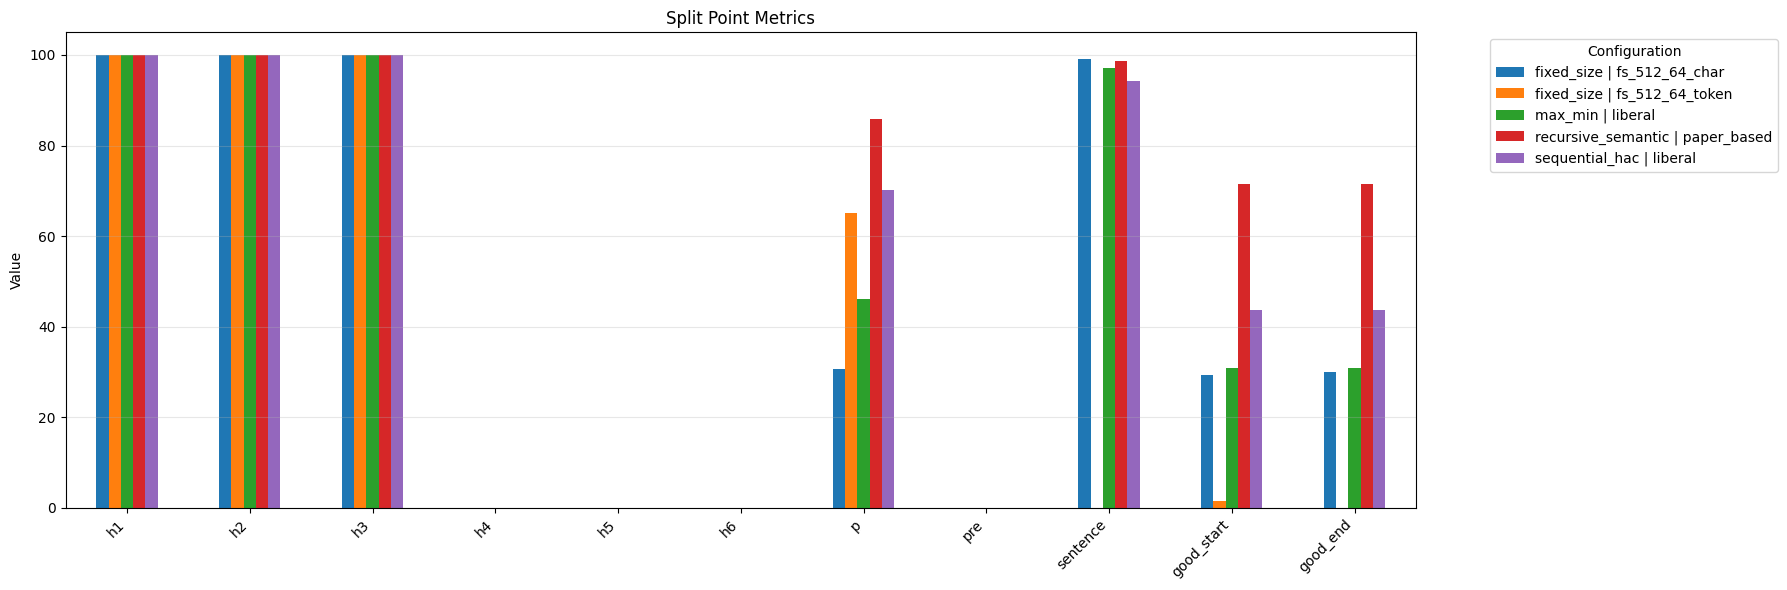

Brak danych


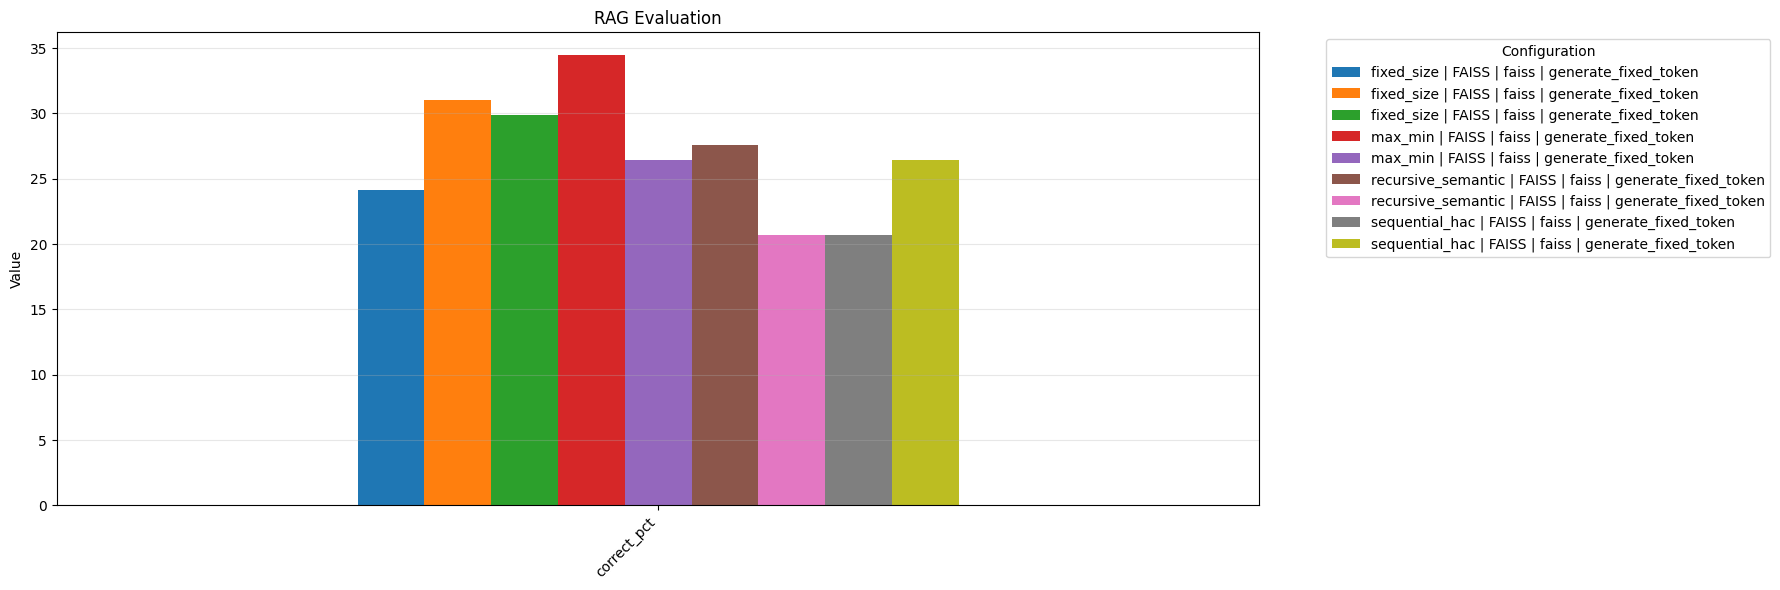

In [10]:
analyzer = ChunkerAnalyzer()

# IMPORTANT
analyzer.retrieval_base_path = (
    Path("data/analyze_retrieval")
    / analyzer.dataset_name
    / analyzer.dataset_param_name
)

# ------------------------------------------------------------
# split
# ------------------------------------------------------------

df_split = analyzer.analyze(
    splits=["example"]
)

display(df_split)

# ------------------------------------------------------------
# rag
# ------------------------------------------------------------

df_rag = analyzer.analyze_rag()

display(df_rag)

# ------------------------------------------------------------
# retrieval
# ------------------------------------------------------------

df_ret = analyzer.analyze_retrieval()

display(df_ret)

# ------------------------------------------------------------
# combined
# ------------------------------------------------------------

df_combined = analyzer.analyze_combined()

display(df_combined)

# ------------------------------------------------------------
# plots
# ------------------------------------------------------------
plot_comparison(
    df_split,
    title="Split Point Metrics",
    columns=[
        "h1", "h2", "h3", "h4", "h5", "h6",
        "p", "pre",
        "sentence",
        "good_start",
        "good_end",
    ],
    label_levels=[
        "chunker_name",
        "chunker_param_name",
    ],
)

plot_comparison(
    df_ret[df_ret.index == "example"],
    title="Retrieval Metrics",
    label_levels=[
        "chunker_name",
        "embed_name",
        "search_name",
    ]
)
plot_comparison(
    df_rag,
    title="RAG Evaluation",
    columns=["correct_pct"],
    label_levels=[
        "chunker_name",
        "embed_name",
        "search_name",
        "generator_name",
    ],
)

In [15]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


ALLOWED_COLUMNS = ["h1", "h2", "h3", "h4", "h5", "h6", "p", "pre", 'sentence', 'good_start', 'good_end']


# ============================================================
# CONFIG
# ============================================================

@dataclass
class ImportanceConfig:
    """
    Konfiguracja modelu importance.
    Dzięki temu łatwo później podmienić model / preprocessing.
    """
    model_factory: Callable[[], object]
    use_scaling: bool = True
    nan_strategy: str = "median"


DEFAULT_CONFIG = ImportanceConfig(
    model_factory=lambda: LogisticRegression(
        max_iter=5000,
        random_state=42,
    )
)


# ============================================================
# CORE
# ============================================================

class FeatureImportanceAnalyzer:
    def __init__(
        self,
        df_split: pd.DataFrame,
        df_rag: pd.DataFrame,
        config: ImportanceConfig = DEFAULT_CONFIG,
    ):
        self.df_split = df_split.copy()
        self.df_rag = df_rag.copy()
        self.config = config

        self._validate_inputs()
        self.X = self._prepare_features()

    def _validate_inputs(self) -> None:
        return
        required_index_names = {"chunker", "params"}

        split_index_names = set(self.df_split.index.names)
        rag_index_names = set(self.df_rag.index.names)

        if split_index_names != required_index_names:
            raise ValueError(
                f"df_split musi mieć indeksy: {required_index_names}, "
                f"aktualnie: {split_index_names}"
            )

        if rag_index_names != required_index_names:
            raise ValueError(
                f"df_rag musi mieć indeksy: {required_index_names}, "
                f"aktualnie: {rag_index_names}"
            )

    def _prepare_features(self) -> pd.DataFrame:
        """
        Zachowujemy tylko kolumny z ALLOWED_COLUMNS
        i pilnujemy odpowiedniej kolejności.
        """
        existing_columns = [
            col for col in ALLOWED_COLUMNS
            if col in self.df_split.columns
        ]

        if not existing_columns:
            raise ValueError(
                "Brak kolumn z ALLOWED_COLUMNS w df_split."
            )

        return self.df_split[existing_columns]

    def _build_pipeline(self) -> Pipeline:
        steps = [
            ("imputer", SimpleImputer(strategy=self.config.nan_strategy)),
        ]

        if self.config.use_scaling:
            steps.append(("scaler", StandardScaler()))

        steps.append(("model", self.config.model_factory()))

        return Pipeline(steps)

    @staticmethod
    def _prepare_target(y: pd.Series) -> pd.Series:
        """
        LogisticRegression wymaga targetu klasowego.
        Zakładam tutaj binaryzację:
        > mediany => 1
        <= mediany => 0

        Łatwo później zmienić strategię.
        """
        threshold = y.median()
        return (y > threshold).astype(int)

    def calculate_importance(self) -> dict[str, pd.Series]:
        results: dict[str, pd.Series] = {}

        for target_col in self.df_rag.columns:
            y_raw = self.df_rag[target_col]

            # wspólny index
            common_idx = self.X.index.intersection(y_raw.index)

            X = self.X.loc[common_idx]
            y = y_raw.loc[common_idx]

            # usuwamy NaN z y
            valid_mask = y.notna()

            X = X.loc[valid_mask]
            y = y.loc[valid_mask]

            # binary target
            y_binary = self._prepare_target(y)

            pipeline = self._build_pipeline()
            pipeline.fit(X, y_binary)

            model = pipeline.named_steps["model"]

            # współczynniki regresji logistycznej
            coefficients = model.coef_[0]

            # sklearn >= 1.0
            feature_names = pipeline[:-1].get_feature_names_out()

            importance = pd.Series(
                coefficients,
                index=feature_names,
                name=target_col,
            )

            # sort po absolute importance
            importance = importance.reindex(ALLOWED_COLUMNS)

            results[target_col] = importance

        return results

    @staticmethod
    def print_importance(results: dict[str, pd.Series]) -> None:
        """
        Jeden print per kolumna z df_rag.
        """
        for target_col, importance in results.items():
            print("=" * 80)
            print(f"RAG COLUMN: {target_col}")
            print("=" * 80)

            for feature_name, weight in importance.items():
                print(f"{feature_name:<5} -> {weight:>12.6f}")

            print("\n")


# ============================================================
# USAGE
# ============================================================

analyzer = FeatureImportanceAnalyzer(
    df_split=df_split,
    df_rag=df_rag,
)

results = analyzer.calculate_importance()

analyzer.print_importance(results)

ValueError: Length of names must match number of levels in MultiIndex.

In [1]:
from src.tools.read.embeddings.load_embeddings import load_embeddings_dataframe, load_multiple_embeddings_dataframes
from src.tools.read.datasets.load_metadata import load_bookmeta_dataframe, load_multiple_bookmeta_dataframes

df_embedding = load_embeddings_dataframe(
    embed_dir="data/vector_db",
    dataset_name="literaryQA",
    dataset_params_name="default",
    chunking_name="fixed_size",
    chunking_params_name="fs_512_64_token",
    embed_name="FAISS",
    embed_params_name="default_global",
    split_name="examples",
)


In [2]:
df_embedding = load_multiple_embeddings_dataframes(
    embed_dir="data/vector_db",
    dataset_names=["literaryQA"],
    dataset_params_names=["default"],
    chunking_names=["fixed_size"],
    chunking_params_names=["fs_512_64_token", "fs_512_64_char"],
    embed_names=["FAISS"],
    embed_params_names=["default_global"],
    split_names=["examples"],
)

In [3]:
df_bookmeta = load_bookmeta_dataframe(
    data_dir="data/datasets",
    dataset_name="literaryQA",
    dataset_params_name="default",
)


In [5]:
df_merged = df_embedding.join(df_bookmeta, how="left", validate="many_to_one")

In [6]:
df_merged

id  \
dataset_name dataset_params_name chunking_name chunking_params_name embed_name embed_params_name split_name source_file chunk_id        
literaryQA   default             fixed_size    fs_512_64_char       FAISS      default_global    examples   1345        2006      184   
                                                                                                                        2007      185   
                                                                                                                        2008      186   
                                                                                                                        2009      187   
                                                                                                                        2010      188   
...                                                                                                                               ...   
                                               fs_512_64_token      FAISS      default_global    examples   1826        617        34   
                                                                                                                        618        35   
                                                                                                                        619        36   
                                                                                                                        620        37   
                                                                                                                        621        38   

                                                                                                                                  embed_time  \
dataset_name dataset_params_name chunking_name chunking_params_name embed_name embed_params_name split_name source_file chunk_id               
literaryQA   default             fixed_size    fs_512_64_char       FAISS      default_global    examples   1345        2006        0.233691   
                                                                                                                        2007        0.233691   
                                                                                                                        2008        0.233691   
                                                                                                                        2009        0.233691   
                                                                                                                        2010        0.233691   
...                                                                                                                                      ...   
                                               fs_512_64_token      FAISS      default_global    examples   1826        617         0.050580   
                                                                                                                        618         0.050580   
                                                                                                                        619         0.050580   
                                                                                                                        620         0.050580   
                                                                                                                        621         0.050580   

                                                                                                                                                                          embedding  \
dataset_name dataset_params_name chunking_name chunking_params_name embed_name embed_params_name split_name source_file chunk_id                                                      
literaryQA   default             fixed_size    fs_512_64_char       FAISS      default_global    examples   13

In [4]:
!python -c "import torch; print(torch.__version__)"

2.10.0+cu128


In [16]:
import torch

def check_gpu():
    if torch.cuda.is_available():
        print("GPU jest dostępne ✅")
        print(f"Nazwa GPU: {torch.cuda.get_device_name(0)}")
        print(f"Liczba GPU: {torch.cuda.device_count()}")
        print(f"Aktualne urządzenie: {torch.cuda.current_device()}")
    else:
        print("GPU nie jest dostępne ❌")

check_gpu()

GPU nie jest dostępne ❌
